# GCN for Illicit Bitcoin Transaction Detection (Elliptic Dataset)

This notebook applies a **two-layer Graph Convolutional Network (GCN)** (Kipf & Welling, 2017) to a real
anti-money-laundering problem: deciding whether a Bitcoin transaction is **licit** or **illicit**
(scams, ransomware, darknet markets, Ponzi schemes, ...).

**Problem → Graph → GCN → Output**

| Step | In this notebook |
|---|---|
| Problem | Flag suspicious Bitcoin transactions |
| Graph | Node = transaction, edge = bitcoin flowing from one transaction to the next |
| GCN | Learns from each transaction's own 165 features **and** those of the transactions it is connected to |
| Output | Probability that each transaction is illicit |

As in the reference implementation, the graph convolution is written **from scratch** in plain PyTorch:
we build the normalised adjacency matrix

$$\hat A = \tilde D^{-1/2}\,\tilde A\,\tilde D^{-1/2},\qquad \tilde A = A + I,$$

and every layer is just $H^{(l+1)} = \sigma\big(\hat A\,H^{(l)}W^{(l)}\big)$ — no `GCNConv` or other pre-built graph layer.

**What makes this dataset different from Cora / Amazon Photo**
* Strong **class imbalance** (≈ 9.8 % of labelled transactions are illicit) → accuracy is misleading, we report **illicit precision / recall / F1**.
* **Time**: the 49 time steps are separate graphs. We use the standard **temporal split** of Weber et al. (2019): train on time steps 1–34, test on 35–49.
* Strong **tabular baselines** (Random Forest) exist, so we check honestly whether the graph helps.

In [1]:
import os, time, random
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             confusion_matrix, average_precision_score)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

set_seed(42)
torch.set_num_threads(os.cpu_count())
os.makedirs("figures", exist_ok=True)

# colours used in every figure
C_LICIT, C_ILLICIT, C_UNKNOWN = "#2a78d6", "#eb6834", "#b4b2ab"
C_MODEL = {"GCN": "#2a78d6", "Skip-GCN": "#eb6834", "MLP": "#1baf7a", "Random Forest": "#4a3aa7",
           "Logistic Regression": "#e87ba4"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

print("PyTorch", torch.__version__, "| NumPy", np.__version__, "| pandas", pd.__version__)

PyTorch 2.14.0+cu130 | NumPy 2.4.4 | pandas 3.0.2


## 1. Load the Elliptic dataset

The dataset was released by Elliptic (Weber et al., 2019). It contains three CSV files:

* `elliptic_txs_features.csv` — one row per transaction: `txId`, `time_step`, then **165 anonymised features**
  (93 *local* features of the transaction itself — inputs/outputs, fees, volume, … — and 72 *aggregated* features
  summarising its one-hop neighbours).
* `elliptic_txs_classes.csv` — label per transaction: `1` = illicit, `2` = licit, `unknown`.
* `elliptic_txs_edgelist.csv` — directed edges `txId1 → txId2` (the output of one transaction is spent in the next).

**Getting the data:** download it from Kaggle (<https://www.kaggle.com/datasets/ellipticco/elliptic-data-set>) and unzip it
into `data/elliptic_bitcoin_dataset/`. If the folder is missing, the cell below lets PyTorch Geometric download the same
three files (PyG is only used as a downloader, never for the model).

In [2]:
FILES = ["elliptic_txs_features.csv", "elliptic_txs_classes.csv", "elliptic_txs_edgelist.csv"]

def locate_raw_files(data_dir="data/elliptic_bitcoin_dataset"):
    if all(os.path.exists(os.path.join(data_dir, f)) for f in FILES):
        return data_dir
    from torch_geometric.datasets import EllipticBitcoinDataset   # downloader only
    EllipticBitcoinDataset("data/pyg_elliptic")
    return "data/pyg_elliptic/raw"

raw_dir = locate_raw_files()
t0 = time.time()
feat_df  = pd.read_csv(os.path.join(raw_dir, FILES[0]), header=None)
class_df = pd.read_csv(os.path.join(raw_dir, FILES[1]))
edge_df  = pd.read_csv(os.path.join(raw_dir, FILES[2]))
print(f"loaded from {raw_dir} in {time.time()-t0:.1f}s")
print("features:", feat_df.shape, "| classes:", class_df.shape, "| edges:", edge_df.shape)

loaded from data/elliptic_bitcoin_dataset in 7.0s
features: (203769, 167) | classes: (203769, 2) | edges: (234355, 2)


In [3]:
tx_ids    = feat_df[0].values
time_step = feat_df[1].values.astype(int)
X_all     = feat_df.iloc[:, 2:].values.astype(np.float32)        # 165 features
LOCAL, AGG = slice(0, 93), slice(93, 165)                         # 93 local + 72 aggregated

N = len(tx_ids)
pos = pd.Series(np.arange(N), index=tx_ids)                        # txId -> row index

label_str = class_df.set_index("txId").loc[tx_ids, "class"].astype(str).values
y_np = np.full(N, -1, dtype=np.int64)          # -1 unknown, 0 licit, 1 illicit
y_np[label_str == "2"] = 0
y_np[label_str == "1"] = 1

src = pos[edge_df["txId1"].values].values
dst = pos[edge_df["txId2"].values].values

n_ill, n_lic, n_unk = (y_np == 1).sum(), (y_np == 0).sum(), (y_np == -1).sum()
print(f"transactions (nodes): {N:,}")
print(f"directed edges       : {len(src):,}")
print(f"features per node    : {X_all.shape[1]} (93 local + 72 aggregated)")
print(f"time steps           : {time_step.min()} .. {time_step.max()}")
print(f"illicit / licit / unknown : {n_ill:,} / {n_lic:,} / {n_unk:,}")
print(f"illicit share of labelled : {n_ill/(n_ill+n_lic):.2%}")

transactions (nodes): 203,769
directed edges       : 234,355
features per node    : 165 (93 local + 72 aggregated)
time steps           : 1 .. 49
illicit / licit / unknown : 4,545 / 42,019 / 157,205
illicit share of labelled : 9.76%


## 2. Explore the graph

Before modelling we check the properties that decide whether a GCN can help:

* **Degree** — how many neighbours a transaction has (the GCN averages over them).
* **Time structure** — do edges ever cross time steps?
* **Connected components** — how fragmented the graph is.
* **Homophily** — do illicit transactions tend to be linked to illicit ones?

In [4]:
# undirected, de-duplicated adjacency (scipy) for statistics
A_sp = sp.coo_matrix((np.ones(len(src)), (src, dst)), shape=(N, N)).tocsr()
A_und = ((A_sp + A_sp.T) > 0).astype(np.float32)
deg = np.asarray(A_und.sum(1)).ravel()
n_und_edges = int(A_und.nnz // 2)

cross_time = (time_step[src] != time_step[dst]).sum()
n_comp, comp = connected_components(A_und, directed=False)
comp_sizes = np.bincount(comp)

print(f"undirected edges        : {n_und_edges:,}")
print(f"average degree          : {deg.mean():.2f}   (median {np.median(deg):.0f}, max {deg.max():.0f})")
print(f"edges crossing time steps: {cross_time}")
print(f"connected components    : {n_comp:,}  (largest {comp_sizes.max():,} nodes)")

# homophily on edges whose two ends are both labelled
lab = (y_np[src] >= 0) & (y_np[dst] >= 0)
same = (y_np[src][lab] == y_np[dst][lab]).mean()
print(f"labelled-labelled edges : {lab.sum():,}  -> edge homophily {same:.3f}")

# neighbourhood of illicit vs licit nodes: share of labelled neighbours that are illicit
def illicit_neighbour_share(cls):
    rows = np.where(y_np == cls)[0]
    sub = A_und[rows]
    lab_nb = sub.multiply((y_np >= 0)[None, :]).sum(1).A.ravel()
    ill_nb = sub.multiply((y_np == 1)[None, :]).sum(1).A.ravel()
    m = lab_nb > 0
    return ill_nb[m].sum() / lab_nb[m].sum()

print(f"P(neighbour illicit | node illicit) = {illicit_neighbour_share(1):.3f}")
print(f"P(neighbour illicit | node licit)   = {illicit_neighbour_share(0):.3f}")
print(f"base rate of illicit among labelled = {n_ill/(n_ill+n_lic):.3f}")

undirected edges        : 234,355
average degree          : 2.30   (median 2, max 473)
edges crossing time steps: 0
connected components    : 49  (largest 7,880 nodes)
labelled-labelled edges : 36,624  -> edge homophily 0.954
P(neighbour illicit | node illicit) = 0.541
P(neighbour illicit | node licit)   = 0.024
base rate of illicit among labelled = 0.098


/tmp/ipykernel_6591/2418304839.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ax[0].axvline(34.5, color="k", ls="--", lw=1); ax[0].text(35, cnt[["licit","illicit"]].sum(1).max()*0.95, "test →", fontsize=9)
/tmp/ipykernel_6591/2418304839.py:10: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ax[0].text(34, cnt[["licit","illicit"]].sum(1).max()*0.95, "← train", ha="right", fontsize=9)


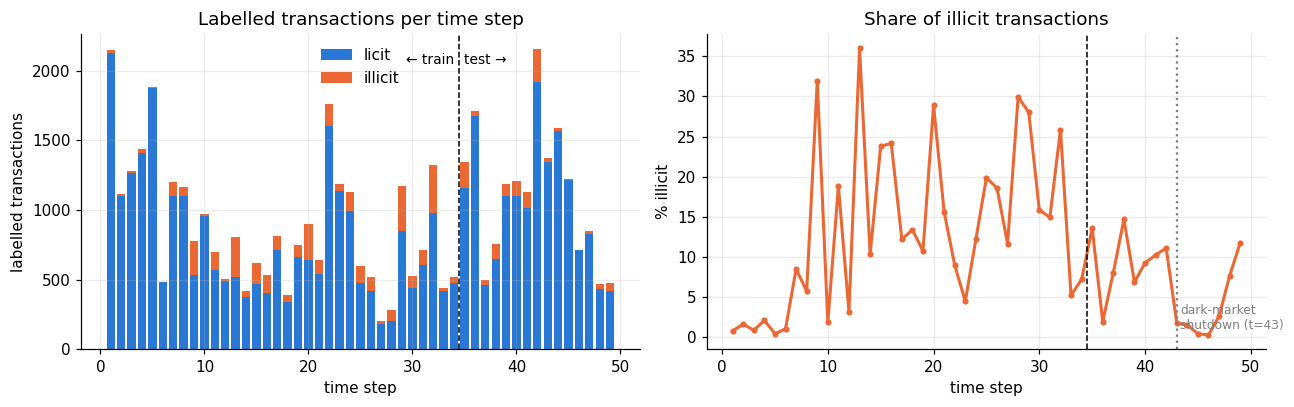

In [5]:
ts = np.arange(1, 50)
cnt = pd.DataFrame({"illicit": [(y_np[time_step == t] == 1).sum() for t in ts],
                    "licit":   [(y_np[time_step == t] == 0).sum() for t in ts],
                    "unknown": [(y_np[time_step == t] == -1).sum() for t in ts]}, index=ts)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(ts, cnt["licit"], color=C_LICIT, label="licit", width=0.8)
ax[0].bar(ts, cnt["illicit"], bottom=cnt["licit"], color=C_ILLICIT, label="illicit", width=0.8)
ax[0].axvline(34.5, color="k", ls="--", lw=1); ax[0].text(35, cnt[["licit","illicit"]].sum(1).max()*0.95, "test →", fontsize=9)
ax[0].text(34, cnt[["licit","illicit"]].sum(1).max()*0.95, "← train", ha="right", fontsize=9)
ax[0].set(xlabel="time step", ylabel="labelled transactions", title="Labelled transactions per time step")
ax[0].legend(frameon=False)
ax[1].plot(ts, cnt["illicit"] / (cnt["illicit"] + cnt["licit"]) * 100, color=C_ILLICIT, lw=2, marker="o", ms=3)
ax[1].axvline(34.5, color="k", ls="--", lw=1); ax[1].axvline(43, color="grey", ls=":", lw=1.5)
ax[1].text(43.3, 1, "dark-market\nshutdown (t=43)", fontsize=8, color="grey")
ax[1].set(xlabel="time step", ylabel="% illicit", title="Share of illicit transactions")
plt.tight_layout(); plt.savefig("figures/dataset_timesteps.png", dpi=200, bbox_inches="tight"); plt.show()

### A look at the real graph

Below is the two-hop neighbourhood of one illicit transaction from the test period. Arrows follow the flow of bitcoin
(output of one transaction spent by the next) — exactly the *Wallet → Tx → Tx → Tx* chain from the problem statement.

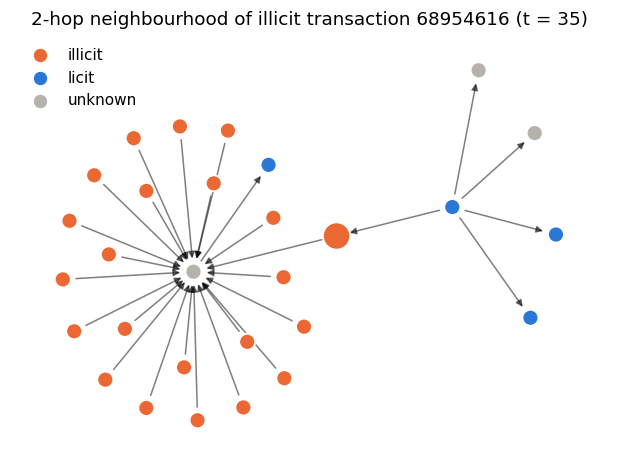

nodes in view: 29 | labels: {np.int64(-1): 3, np.int64(0): 4, np.int64(1): 22}


In [6]:
G_dir = nx.DiGraph(); G_dir.add_edges_from(zip(src, dst))
G_und = G_dir.to_undirected(as_view=True)
# first illicit test transaction whose 2-hop neighbourhood is small enough to draw and mixes all three label types
for center in np.where((y_np == 1) & (time_step >= 35))[0]:
    if not 2 <= deg[center] <= 10:
        continue
    ego = nx.ego_graph(G_und, center, radius=2)
    labs = y_np[list(ego.nodes())]
    if 15 <= len(labs) <= 40 and min((labs == 1).sum(), (labs == 0).sum(), (labs == -1).sum()) >= 3:
        break
sub = G_dir.subgraph(ego.nodes())
colors = [C_ILLICIT if y_np[v] == 1 else C_LICIT if y_np[v] == 0 else C_UNKNOWN for v in sub.nodes()]
sizes  = [320 if v == center else 110 for v in sub.nodes()]
pos_l = nx.kamada_kawai_layout(sub.to_undirected())
plt.figure(figsize=(7, 5))
nx.draw_networkx_edges(sub, pos_l, alpha=0.5, arrows=True, arrowsize=9, width=1)
nx.draw_networkx_nodes(sub, pos_l, node_color=colors, node_size=sizes, edgecolors="white", linewidths=1.2)
for c, l in [(C_ILLICIT, "illicit"), (C_LICIT, "licit"), (C_UNKNOWN, "unknown")]:
    plt.scatter([], [], c=c, s=60, label=l)
plt.legend(frameon=False, loc="best"); plt.axis("off")
plt.title(f"2-hop neighbourhood of illicit transaction {tx_ids[center]} (t = {time_step[center]})")
plt.savefig("figures/ego_graph.png", dpi=200, bbox_inches="tight"); plt.show()
print("nodes in view:", sub.number_of_nodes(), "| labels:",
      {k: int(v) for k, v in zip(*np.unique(y_np[list(sub.nodes())], return_counts=True))})

## 3. Temporal train / test split

Transactions are ordered in time, so a random split would let the model train on the future.
Following Weber et al. (2019) we train on **time steps 1–34** and test on **time steps 35–49**.
Only labelled nodes enter the loss or the metrics; unlabelled nodes stay in the graph and pass messages.

Because no edge crosses a time step, the test transactions live in graphs the model never saw during training —
the GCN has to **generalise inductively to new graphs**, not just to new nodes in a known graph (unlike Cora or Amazon Photo).

Features are standardised with the mean / standard deviation of the training period (time steps 1–34).

In [7]:
train_mask_np = (y_np >= 0) & (time_step <= 34)
test_mask_np  = (y_np >= 0) & (time_step >= 35)

mu = X_all[time_step <= 34].mean(0); sd = X_all[time_step <= 34].std(0) + 1e-6
X_std = (X_all - mu) / sd

X_af = torch.tensor(X_std)                 # all 165 features
X_lf = torch.tensor(X_std[:, LOCAL])       # 93 local features only
y    = torch.tensor(y_np)
train_mask, test_mask = torch.tensor(train_mask_np), torch.tensor(test_mask_np)

for name, m in [("train (t 1-34)", train_mask_np), ("test (t 35-49)", test_mask_np)]:
    print(f"{name}: {m.sum():6,} labelled | illicit {(y_np[m]==1).sum():5,} ({(y_np[m]==1).mean():.1%})")
print(f"\nAccuracy of always predicting 'licit' on test: {(y_np[test_mask_np]==0).mean():.2%}  (illicit F1 = 0)")

train (t 1-34): 29,894 labelled | illicit 3,462 (11.6%)
test (t 35-49): 16,670 labelled | illicit 1,083 (6.5%)

Accuracy of always predicting 'licit' on test: 93.50%  (illicit F1 = 0)


## 4. The normalised adjacency matrix $\hat A$

We treat the transaction graph as undirected (information about a suspicious transaction is relevant in both directions of
the money flow), add self-loops, and normalise symmetrically:

$$\hat A_{ij} = \frac{\tilde A_{ij}}{\sqrt{\tilde d_i\,\tilde d_j}},\qquad \tilde d_i = \sum_j \tilde A_{ij}.$$

A dense $203{,}769 \times 203{,}769$ matrix would need about **166 GB** in float32, so $\hat A$ is stored as a sparse tensor.

In [8]:
def build_norm_adj(src, dst, n):
    src, dst = torch.as_tensor(src), torch.as_tensor(dst)
    loops = torch.arange(n)
    row = torch.cat([src, dst, loops])          # both directions + self-loops  -> A~ = A + I
    col = torch.cat([dst, src, loops])
    key = torch.unique(row * n + col)           # remove duplicate edges
    row, col = key // n, key % n
    d = torch.zeros(n).scatter_add_(0, row, torch.ones(row.numel()))   # D~_ii
    w = d[row].pow(-0.5) * d[col].pow(-0.5)                             # D~^-1/2 A~ D~^-1/2
    return torch.sparse_coo_tensor(torch.stack([row, col]), w, (n, n)).coalesce()

def identity_adj(n):                            # A_hat = I  turns the GCN into an MLP
    i = torch.arange(n)
    return torch.sparse_coo_tensor(torch.stack([i, i]), torch.ones(n), (n, n)).coalesce()

A_hat = build_norm_adj(src, dst, N)
I_hat = identity_adj(N)
print("A_hat:", tuple(A_hat.shape), "| non-zeros:", f"{A_hat._nnz():,}",
      f"| density {A_hat._nnz()/N**2:.2e}")
print("dense float32 size would be", f"{N*N*4/1e9:.0f} GB")

# sanity check: A_hat is symmetric and its largest eigenvalue is 1
v = torch.sparse.sum(A_hat, 1).to_dense()
print("row sums: min %.3f  max %.3f" % (v.min(), v.max()))

/tmp/ipykernel_6591/3051347913.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  src, dst = torch.as_tensor(src), torch.as_tensor(dst)
/tmp/ipykernel_6591/3051347913.py:10: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:848.)
  return torch.sparse_coo_t

A_hat: (203769, 203769) | non-zeros: 672,479 | density 1.62e-05
dense float32 size would be 166 GB
row sums: min 0.363  max 12.396


## 5. The GCN, written from scratch

One layer is literally $\hat A\,(H W) + b$. The two-layer model is

$$Z = \hat A\;\mathrm{ReLU}\!\big(\hat A\,X\,W^{(0)}\big)\,W^{(1)}, \qquad P = \mathrm{softmax}(Z).$$

We also build two variants with the same code:

* **MLP** – the same network with $\hat A$ replaced by $I$ (no graph).  Comparing it with the GCN isolates what the graph adds.
* **Skip-GCN** (Weber et al., 2019) – adds a skip connection from the input features to the output,
  $Z = \hat A\,\mathrm{ReLU}(\hat A X W^{(0)})W^{(1)} + X W_{\text{skip}}$, so the model can keep a transaction's own evidence
  from being washed out by its neighbours.

In [9]:
class GCNLayer(nn.Module):
    '''H_out = A_hat @ (H W) + b'''
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Parameter(torch.empty(in_dim, out_dim))
        self.b = nn.Parameter(torch.zeros(out_dim))
        nn.init.xavier_uniform_(self.W)
    def forward(self, A, H, AH=None):
        if AH is not None:                       # A_hat @ H already known:  A_hat (H W) = (A_hat H) W
            return AH @ self.W + self.b
        return torch.sparse.mm(A, H @ self.W) + self.b

class GCN(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim=2, n_layers=2, dropout=0.0, skip=False):
        super().__init__()
        dims = [in_dim] + [hid_dim] * (n_layers - 1) + [out_dim]
        self.layers = nn.ModuleList(GCNLayer(dims[k], dims[k + 1]) for k in range(n_layers))
        self.skip = nn.Linear(in_dim, out_dim, bias=False) if skip else None
        self.dropout = dropout
    def forward(self, A, X, AX=None, return_hidden=False):
        H, hidden = X, None
        for k, layer in enumerate(self.layers):
            if k == 0 and AX is not None and self.dropout == 0:
                H = layer(A, X, AH=AX)           # first layer re-uses the pre-computed A_hat X
            else:
                H = layer(A, F.dropout(H, self.dropout, self.training))
            if k < len(self.layers) - 1:
                H = F.relu(H); hidden = H
        if self.skip is not None:
            H = H + self.skip(X)
        return (H, hidden) if return_hidden else H

m = GCN(165, 100)
print(m)
print("trainable parameters:", sum(p.numel() for p in m.parameters()))

GCN(
  (layers): ModuleList(
    (0-1): 2 x GCNLayer()
  )
)
trainable parameters: 16802


## 6. Loss, training loop and metrics

With only ~10 % illicit transactions an unweighted loss would push the model towards "always licit".
We use the **weighted cross-entropy** of Weber et al. (weights 0.3 for licit, 0.7 for illicit):

$$\mathcal L = -\frac{1}{\sum_{i\in\mathcal Y_L} w_{y_i}} \sum_{i \in \mathcal Y_L} w_{y_i}\,\log P_{i,y_i}.$$

Hyperparameters are fixed in advance and **not tuned on the test set**: hidden size 100 (as in Weber et al.), and the defaults of
Kipf & Welling — Adam with learning rate 0.01, weight decay $5\times10^{-4}$, 200 full-batch epochs. We use no dropout
(as Weber et al.), which also lets us pre-compute $\hat A X$ once, since $\hat A(XW^{(0)}) = (\hat A X)W^{(0)}$.
We report the model **after the last epoch** — the test curve is recorded only for plotting.

**Metrics.** Illicit **precision** (of the transactions we flag, how many are really illicit), **recall** (how many illicit
transactions we catch) and their harmonic mean, the **illicit F1** — the headline metric of the Elliptic benchmark.
We also report micro-F1 (= accuracy) and the area under the precision-recall curve (AP).

In [10]:
CLASS_W = torch.tensor([0.3, 0.7])
HP = dict(hid=100, lr=1e-2, epochs=200, wd=5e-4, dropout=0.0)

def scores(y_true, y_pred, p_illicit=None):
    out = dict(precision=precision_score(y_true, y_pred, zero_division=0),
               recall=recall_score(y_true, y_pred, zero_division=0),
               f1=f1_score(y_true, y_pred, zero_division=0),
               micro_f1=accuracy_score(y_true, y_pred))
    if p_illicit is not None:
        out["ap"] = average_precision_score(y_true, p_illicit)
    return out

def train_gcn(A, X, seed=42, n_layers=2, skip=False, log_every=0, record=False, **hp):
    hp = {**HP, **hp}
    set_seed(seed)
    model = GCN(X.shape[1], hp["hid"], 2, n_layers=n_layers, dropout=hp["dropout"], skip=skip)
    opt = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["wd"])
    AX = torch.sparse.mm(A, X)       # A_hat and X never change, so A_hat X is computed once
    hist = []
    ytr, yte = y[train_mask], y[test_mask]
    for ep in range(1, hp["epochs"] + 1):
        model.train()
        out = model(A, X, AX)
        loss = F.cross_entropy(out[train_mask], ytr, weight=CLASS_W)
        opt.zero_grad(); loss.backward(); opt.step()
        if record and (ep == 1 or ep % 10 == 0):
            model.eval()
            with torch.no_grad():
                pred = model(A, X, AX).argmax(1)
            hist.append(dict(epoch=ep, loss=loss.item(),
                             train_f1=f1_score(ytr, pred[train_mask]),
                             test_f1=f1_score(yte, pred[test_mask]),
                             train_acc=(pred[train_mask] == ytr).float().mean().item(),
                             test_acc=(pred[test_mask] == yte).float().mean().item()))
            if log_every and (ep == 1 or ep % log_every == 0):
                h = hist[-1]
                print(f"epoch {ep:4d} | loss {h['loss']:.4f} | train F1 {h['train_f1']:.3f} | "
                      f"test F1 {h['test_f1']:.3f} | test acc {h['test_acc']:.3f}")
    model.eval()
    with torch.no_grad():
        logits, hidden = model(A, X, AX, return_hidden=True)
        prob = logits.softmax(1)[:, 1]
    return model, prob.numpy(), hidden, pd.DataFrame(hist)

def eval_probs(prob, mask=test_mask_np):
    return scores(y_np[mask], (prob[mask] >= 0.5).astype(int), prob[mask])

## 7. Train the GCN (seed 42)

In [11]:
t0 = time.time()
gcn, p_gcn, H_gcn, hist_gcn = train_gcn(A_hat, X_af, seed=42, record=True, log_every=100)
print(f"\ntraining time: {time.time()-t0:.0f}s")
print("initial loss:", round(hist_gcn.loss.iloc[0], 4), " (ln 2 = 0.6931 for a 50/50 guess)")
res_gcn = eval_probs(p_gcn)
print({k: round(v, 4) for k, v in res_gcn.items()})

epoch    1 | loss 1.0065 | train F1 0.479 | test F1 0.271 | test acc 0.822


epoch  100 | loss 0.1107 | train F1 0.870 | test F1 0.500 | test acc 0.945


epoch  200 | loss 0.0807 | train F1 0.908 | test F1 0.572 | test acc 0.955



training time: 104s
initial loss: 1.0065  (ln 2 = 0.6931 for a 50/50 guess)
{'precision': 0.7358, 'recall': 0.4681, 'f1': 0.5722, 'micro_f1': 0.9545, 'ap': 0.5926}


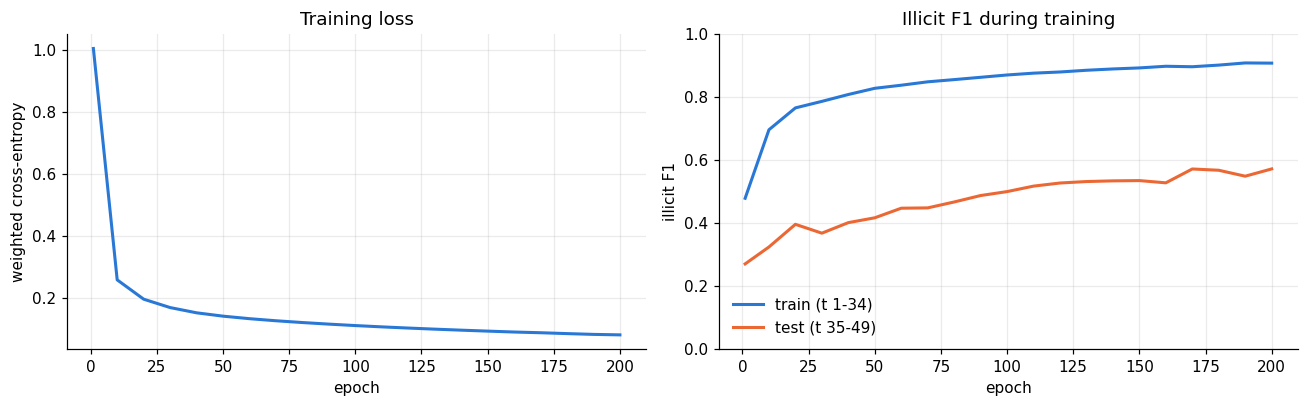

 epoch   loss  train_f1  test_f1  train_acc  test_acc
     1 1.0065    0.4791   0.2707     0.8072    0.8216
    20 0.1961    0.7659   0.3964     0.9407    0.9077
    50 0.1412    0.8282   0.4171     0.9581    0.9256
   100 0.1107    0.8705   0.5003     0.9689    0.9448
   150 0.0928    0.8929   0.5352     0.9744    0.9521
   200 0.0807    0.9080   0.5722     0.9778    0.9545


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(hist_gcn.epoch, hist_gcn.loss, color=C_MODEL["GCN"], lw=2)
ax[0].set(xlabel="epoch", ylabel="weighted cross-entropy", title="Training loss")
ax[1].plot(hist_gcn.epoch, hist_gcn.train_f1, color=C_MODEL["GCN"], lw=2, label="train (t 1-34)")
ax[1].plot(hist_gcn.epoch, hist_gcn.test_f1, color=C_MODEL["Skip-GCN"], lw=2, label="test (t 35-49)")
ax[1].set(xlabel="epoch", ylabel="illicit F1", title="Illicit F1 during training", ylim=(0, 1))
ax[1].legend(frameon=False)
plt.tight_layout(); plt.savefig("figures/training_curves.png", dpi=200, bbox_inches="tight"); plt.show()
print(hist_gcn[hist_gcn.epoch.isin([1, 20, 50, 100, 150, 200])].round(4).to_string(index=False))

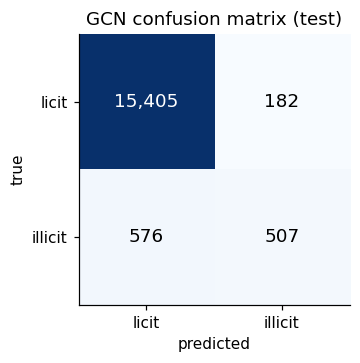

[[15405   182]
 [  576   507]]


In [13]:
cm = confusion_matrix(y_np[test_mask_np], (p_gcn[test_mask_np] >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(3.8, 3.4))
ax.imshow(cm, cmap="Blues"); ax.grid(False)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
ax.set_xticks([0, 1], ["licit", "illicit"]); ax.set_yticks([0, 1], ["licit", "illicit"])
ax.set(xlabel="predicted", ylabel="true", title="GCN confusion matrix (test)")
plt.tight_layout(); plt.savefig("figures/confusion_gcn.png", dpi=200, bbox_inches="tight"); plt.show()
print(cm)

## 8. Baselines, variants and 5 random seeds

To judge the GCN fairly we compare it with:

| Model | Uses graph? | Notes |
|---|---|---|
| Logistic Regression | no | linear, tabular (deterministic) |
| Random Forest | no | 50 trees, `max_features=50` (Weber et al.) |
| MLP | no | *our* network with $\hat A = I$ — same code, same parameters |
| GCN | yes | our 2-layer GCN |
| Skip-GCN | yes | GCN + skip connection from $X$ |

Each is trained on **all features (AF, 165)** and on **local features only (LF, 93)**.
The LF setting is the cleaner test of the graph: the 72 aggregated features are themselves hand-made one-hop
neighbourhood summaries, so with AF part of what the GCN learns is already handed to every model.

A single seed can be lucky, so every stochastic model is trained with **5 seeds** (42, 1, 2, 3, 4) and we report mean ± std.
Seed 42 is kept for the detailed plots.

In [14]:
def run_sklearn(kind, X, seed=42):
    if kind == "Logistic Regression":
        clf = LogisticRegression(max_iter=2000)
    else:
        clf = RandomForestClassifier(n_estimators=50, max_features=50, random_state=seed, n_jobs=-1)
    clf.fit(X[train_mask_np], y_np[train_mask_np])
    prob = np.zeros(N); prob[test_mask_np] = clf.predict_proba(X[test_mask_np])[:, 1]
    return clf, prob

SEEDS = [42, 1, 2, 3, 4]
FEATS = {"AF": (X_std, X_af), "LF": (X_std[:, LOCAL], X_lf)}
NEURAL = [("MLP", I_hat, False), ("GCN", A_hat, False), ("Skip-GCN", A_hat, True)]

rows, probs = [], {}
t0 = time.time()
for feats, (Xn, Xt) in FEATS.items():
    _, p = run_sklearn("Logistic Regression", Xn)
    probs[("Logistic Regression", feats)] = p
    rows.append(dict(model="Logistic Regression", features=feats, seed=0, **eval_probs(p)))
    for s in SEEDS:
        _, p = run_sklearn("Random Forest", Xn, seed=s)
        if s == 42: probs[("Random Forest", feats)] = p
        rows.append(dict(model="Random Forest", features=feats, seed=s, **eval_probs(p)))
        for kind, A, skip in NEURAL:
            if (kind, feats, s) == ("GCN", "AF", 42):
                p = p_gcn                                    # already trained in Section 7
            else:
                _, p, _, _ = train_gcn(A, Xt, seed=s, skip=skip)
            if s == 42: probs[(kind, feats)] = p
            rows.append(dict(model=kind, features=feats, seed=s, **eval_probs(p)))
        print(f"{feats} seed {s:2d} done ({time.time()-t0:.0f}s)")

multi_df = pd.DataFrame(rows)
multi_df.to_csv("figures/all_runs.csv", index=False)

AF seed 42 done (224s)


AF seed  1 done (544s)


AF seed  2 done (858s)


AF seed  3 done (1185s)


AF seed  4 done (1509s)


LF seed 42 done (1779s)


LF seed  1 done (2053s)


LF seed  2 done (2316s)


LF seed  3 done (2587s)


LF seed  4 done (2868s)


In [15]:
# seed 42 only
single = multi_df[multi_df.seed.isin([42, 0])].set_index(["features", "model"])[["precision", "recall", "f1", "micro_f1", "ap"]]
single.round(3)

precision  recall     f1  micro_f1     ap
features model                                                         
AF       Logistic Regression      0.311   0.680  0.427     0.881  0.322
         Random Forest            0.919   0.722  0.809     0.978  0.780
         MLP                      0.566   0.544  0.555     0.943  0.433
         GCN                      0.736   0.468  0.572     0.955  0.593
         Skip-GCN                 0.737   0.476  0.578     0.955  0.581
LF       Logistic Regression      0.393   0.714  0.507     0.910  0.299
         Random Forest            0.849   0.715  0.776     0.973  0.771
         MLP                      0.477   0.734  0.578     0.930  0.536
         GCN                      0.394   0.636  0.487     0.913  0.541
         Skip-GCN                 0.365   0.637  0.464     0.904  0.512

In [16]:
# mean ± std over seeds
summary = (multi_df.groupby(["features", "model"])[["precision", "recall", "f1", "ap"]]
           .agg(["mean", "std"]).round(3))
summary

precision        recall            f1         \
                                  mean    std   mean    std   mean    std   
features model                                                              
AF       GCN                     0.786  0.047  0.439  0.053  0.560  0.034   
         Logistic Regression     0.311    NaN  0.680    NaN  0.427    NaN   
         MLP                     0.556  0.018  0.539  0.027  0.546  0.009   
         Random Forest           0.923  0.012  0.722  0.002  0.810  0.004   
         Skip-GCN                0.756  0.042  0.466  0.038  0.575  0.024   
LF       GCN                     0.428  0.056  0.599  0.050  0.495  0.018   
         Logistic Regression     0.393    NaN  0.714    NaN  0.507    NaN   
         MLP                     0.447  0.025  0.745  0.009  0.559  0.017   
         Random Forest           0.848  0.008  0.705  0.007  0.770  0.004   
         Skip-GCN                0.386  0.020  0.619  0.015  0.475  0.014   

                                 ap         
                               mean    std  
features model                              
AF       GCN                  0.604  0.014  
         Logistic Regression  0.322    NaN  
         MLP                  0.443  0.042  
         Random Forest        0.783  0.002  
         Skip-GCN             0.597  0.032  
LF       GCN                  0.526  0.010  
         Logistic Regression  0.299    NaN  
         MLP                  0.519  0.030  
         Random Forest        0.770  0.002  
         Skip-GCN             0.493  0.017

## 10. Performance over time — the dark-market shutdown

Aggregate numbers hide *when* a model fails. Below we compute the illicit F1 separately for each test time step.
Weber et al. observed that after a large darknet market shut down around time step 43, **no model** could detect the new
illicit behaviour — a reminder that the future does not always look like the past.

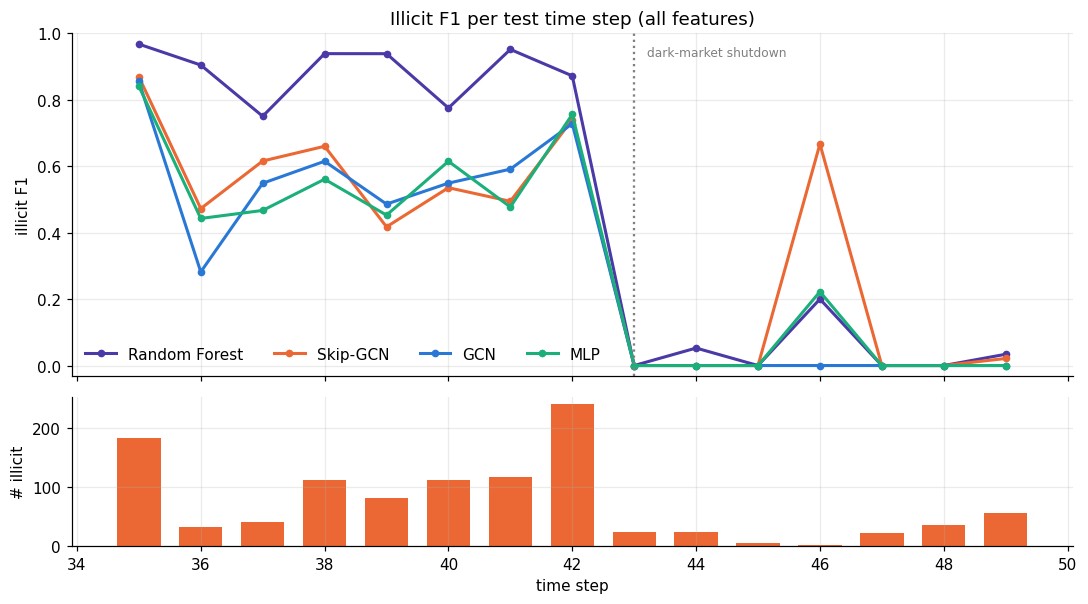

,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
Random Forest,0.967,0.904,0.750,0.938,0.938,0.775,0.951,0.872,0.0,0.053,0.0,0.200,0.0,0.0,0.034
Skip-GCN,0.869,0.472,0.615,0.660,0.417,0.535,0.494,0.740,0.0,0.000,0.0,0.667,0.0,0.0,0.021
GCN,0.855,0.282,0.548,0.615,0.486,0.549,0.591,0.728,0.0,0.000,0.0,0.000,0.0,0.0,0.000
MLP,0.841,0.442,0.467,0.561,0.453,0.615,0.477,0.756,0.0,0.000,0.0,0.222,0.0,0.0,0.000


In [17]:
def f1_per_step(prob):
    out = []
    for t in range(35, 50):
        m = test_mask_np & (time_step == t)
        out.append(f1_score(y_np[m], (prob[m] >= 0.5).astype(int), zero_division=0))
    return np.array(out)

steps = np.arange(35, 50)
per_step = {k: f1_per_step(probs[(k, "AF")]) for k in ["Random Forest", "Skip-GCN", "GCN", "MLP"]}
n_ill_step = [(y_np[test_mask_np & (time_step == t)] == 1).sum() for t in steps]

fig, ax = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True, gridspec_kw={"height_ratios": [2.3, 1]})
for k, v in per_step.items():
    ax[0].plot(steps, v, marker="o", ms=4, lw=2, color=C_MODEL[k], label=k)
ax[0].axvline(43, color="grey", ls=":", lw=1.5); ax[0].text(43.2, 0.93, "dark-market shutdown", color="grey", fontsize=8)
ax[0].set(ylabel="illicit F1", ylim=(-0.03, 1), title="Illicit F1 per test time step (all features)")
ax[0].legend(frameon=False, ncol=4, loc="lower left")
ax[1].bar(steps, n_ill_step, color=C_ILLICIT, width=0.7)
ax[1].set(xlabel="time step", ylabel="# illicit")
plt.tight_layout(); plt.savefig("figures/f1_per_timestep.png", dpi=200, bbox_inches="tight"); plt.show()
pd.DataFrame(per_step, index=steps).round(3).T

## 11. How deep should the GCN be? (over-smoothing)

Each layer mixes a node with its neighbours; after many layers the representations of all nodes in a component become
similar (**over-smoothing**). We train GCNs with 1 to 6 layers (2 seeds each, local features so the model must use the graph)
and also measure the mean pairwise cosine similarity of the last hidden layer on 2,000 random test nodes.

In [18]:
def mean_cosine(H, idx):
    Z = F.normalize(H[idx], dim=1)
    S = Z @ Z.T
    n = len(idx)
    return ((S.sum() - n) / (n * (n - 1))).item()

rng = np.random.default_rng(0)
cos_idx = torch.tensor(rng.choice(np.where(test_mask_np)[0], 2000, replace=False))
depth_rows = []
t0 = time.time()
for L in [1, 2, 3, 4, 6]:
    for s in [42, 1]:
        mdl, p, H, _ = train_gcn(A_hat, X_lf, seed=s, n_layers=L)
        cs = mean_cosine(H, cos_idx) if H is not None else np.nan
        depth_rows.append(dict(layers=L, seed=s, cos=cs, **eval_probs(p)))
    print(f"L={L} done ({time.time()-t0:.0f}s)")
depth_df = pd.DataFrame(depth_rows)
depth_sum = depth_df.groupby("layers")[["f1", "precision", "recall", "cos"]].agg(["mean", "std"]).round(3)
depth_sum

L=1 done (13s)


L=2 done (190s)


L=3 done (646s)


L=4 done (1403s)


L=6 done (2727s)


f1        precision        recall           cos       
         mean    std      mean    std   mean    std   mean    std
layers                                                           
1       0.273  0.002     0.184  0.001  0.535  0.012    NaN    NaN
2       0.501  0.021     0.457  0.089  0.574  0.088  0.410  0.006
3       0.422  0.032     0.425  0.200  0.519  0.217  0.674  0.005
4       0.385  0.004     0.429  0.010  0.349  0.001  0.902  0.014
6       0.336  0.022     0.303  0.083  0.458  0.240  0.849  0.090

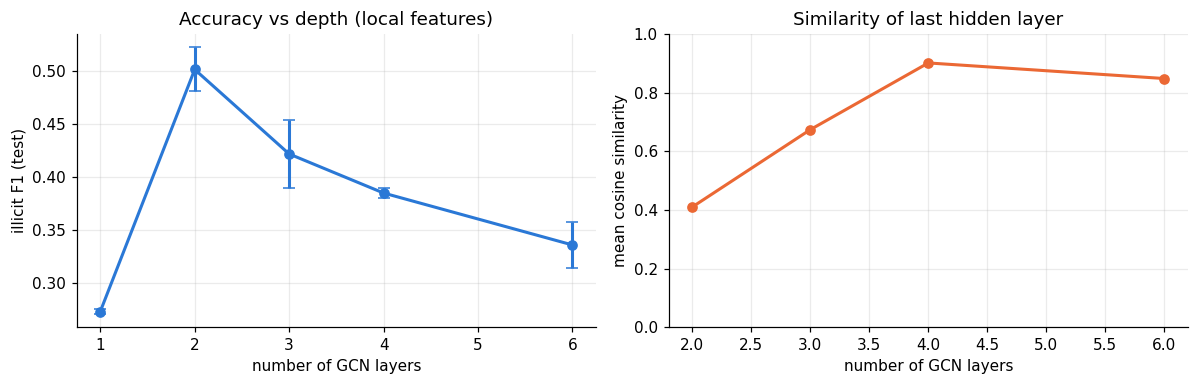

In [19]:
d = depth_df.groupby("layers").agg(f1=("f1", "mean"), f1s=("f1", "std"), cos=("cos", "mean"))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].errorbar(d.index, d.f1, yerr=d.f1s, color=C_MODEL["GCN"], marker="o", lw=2, capsize=4)
ax[0].set(xlabel="number of GCN layers", ylabel="illicit F1 (test)", title="Accuracy vs depth (local features)")
ax[1].plot(d.index[1:], d.cos[1:], color=C_MODEL["Skip-GCN"], marker="o", lw=2)
ax[1].set(xlabel="number of GCN layers", ylabel="mean cosine similarity",
          title="Similarity of last hidden layer", ylim=(0, 1))
plt.tight_layout(); plt.savefig("figures/depth.png", dpi=200, bbox_inches="tight"); plt.show()

## 12. Combining the two worlds: Random Forest + GCN embeddings

Weber et al. reported a small gain from feeding a GCN's learned node embeddings into a Random Forest. The hidden layer
$H^{(1)} = \mathrm{ReLU}(\hat A X W^{(0)})$ of our trained GCN is a 100-dimensional summary of each transaction's neighbourhood;
we concatenate it with the raw features and train a Random Forest.

In [20]:
X_rf_emb = np.hstack([X_std, H_gcn.numpy()])
emb_rows = []
for s in SEEDS:
    _, p = run_sklearn("Random Forest", X_rf_emb, seed=s)
    emb_rows.append(dict(model="RF + GCN embedding", seed=s, **eval_probs(p)))
    if s == 42: probs[("RF + GCN embedding", "AF")] = p
emb_df = pd.DataFrame(emb_rows)
print(emb_df[["precision", "recall", "f1", "ap"]].agg(["mean", "std"]).round(3))

      precision  recall     f1     ap
mean      0.924   0.719  0.809  0.777
std       0.029   0.003  0.010  0.002


## 13. Summary

In [21]:
rows = []
for (feats, model), g in multi_df.groupby(["features", "model"]):
    rows.append(dict(features=feats, model=model, precision=g.precision.mean(), recall=g.recall.mean(),
                     f1=g.f1.mean(), f1_std=g.f1.std(ddof=1) if len(g) > 1 else 0.0, ap=g.ap.mean()))
rows.append(dict(features="AF + emb", model="RF + GCN embedding", precision=emb_df.precision.mean(),
                 recall=emb_df.recall.mean(), f1=emb_df.f1.mean(), f1_std=emb_df.f1.std(), ap=emb_df.ap.mean()))
final = pd.DataFrame(rows).sort_values(["features", "f1"], ascending=[True, False]).round(3)
final.to_csv("figures/final_results.csv", index=False)
final

,features,model,precision,recall,f1,f1_std,ap
3,AF,Random Forest,0.923,0.722,0.810,0.004,0.783
4,AF,Skip-GCN,0.756,0.466,0.575,0.024,0.597
0,AF,GCN,0.786,0.439,0.560,0.034,0.604
2,AF,MLP,0.556,0.539,0.546,0.009,0.443
1,AF,Logistic Regression,0.311,0.680,0.427,0.000,0.322
10,AF + emb,RF + GCN embedding,0.924,0.719,0.809,0.010,0.777
8,LF,Random Forest,0.848,0.705,0.770,0.004,0.770
7,LF,MLP,0.447,0.745,0.559,0.017,0.519
6,LF,Logistic Regression,0.393,0.714,0.507,0.000,0.299
5,LF,GCN,0.428,0.599,0.495,0.018,0.526


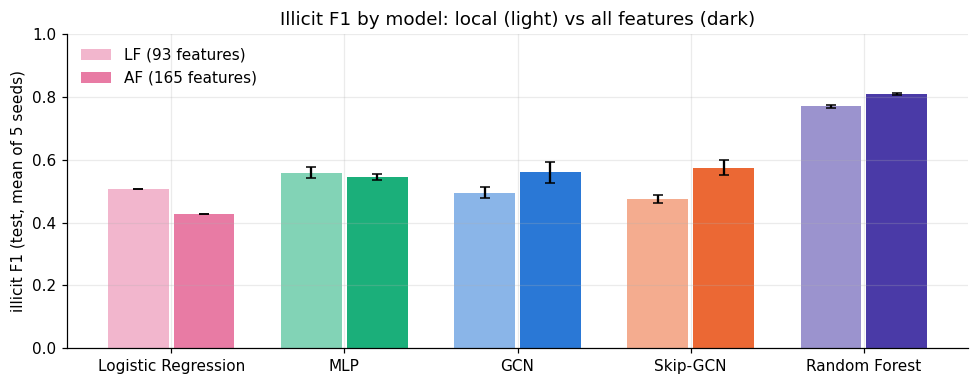

In [22]:
order = ["Logistic Regression", "MLP", "GCN", "Skip-GCN", "Random Forest"]
fig, ax = plt.subplots(figsize=(9, 3.6))
w = 0.38
for k, (feats, off, alpha) in enumerate([("LF", -w/2, 0.55), ("AF", w/2, 1.0)]):
    sub = final[final.features == feats].set_index("model").loc[order]
    ax.bar(np.arange(len(order)) + off, sub.f1, yerr=sub.f1_std, width=w - 0.03, capsize=3,
           color=[C_MODEL[m] for m in order], alpha=alpha, label=f"{feats} ({'93' if feats=='LF' else '165'} features)")
ax.set_xticks(range(len(order)), order)
ax.set(ylabel="illicit F1 (test, mean of 5 seeds)", ylim=(0, 1), title="Illicit F1 by model: local (light) vs all features (dark)")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.savefig("figures/model_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

## 14. Conclusions

* The from-scratch 2-layer GCN reaches an illicit F1 of **0.560 ± 0.034** (5 seeds; 0.572 for seed 42) on future transactions (time steps 35–49).
* **What the graph adds (GCN vs. the same network with $\hat A = I$):** with all features the graph makes the model much more *precise*
  (precision 0.79 vs 0.56) and gives much better *ranking* (AP 0.60 vs 0.44), but F1 at the 0.5 threshold improves only slightly (0.560 vs 0.546).
  With local features only, the GCN does **not** beat the MLP on F1 (0.495 vs 0.559) — consistent with Weber et al., where the MLP (0.653) also beat the GCN (0.628).
* Skip-GCN, which keeps a direct path for each transaction's own features, is the best neural model with all features (0.575).
* A **Random Forest** on the tabular features is the strongest model (0.810), as in the original benchmark; adding GCN embeddings to it does not help here (0.809).
* Two layers are best; deeper GCNs lose accuracy while their hidden representations become more similar — **over-smoothing** in trained models.
* Every model collapses after the **dark-market shutdown** (t ≥ 43): the main open problem on Elliptic is concept drift, not model capacity.

See the accompanying report for the full discussion.